## Conhecendo os dados

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
url = 'https://raw.githubusercontent.com/alura-cursos/classificacao_xgboost/main/Atividades/water_potability.csv'

In [3]:
dados = pd.read_csv(url)
dados.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


In [4]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


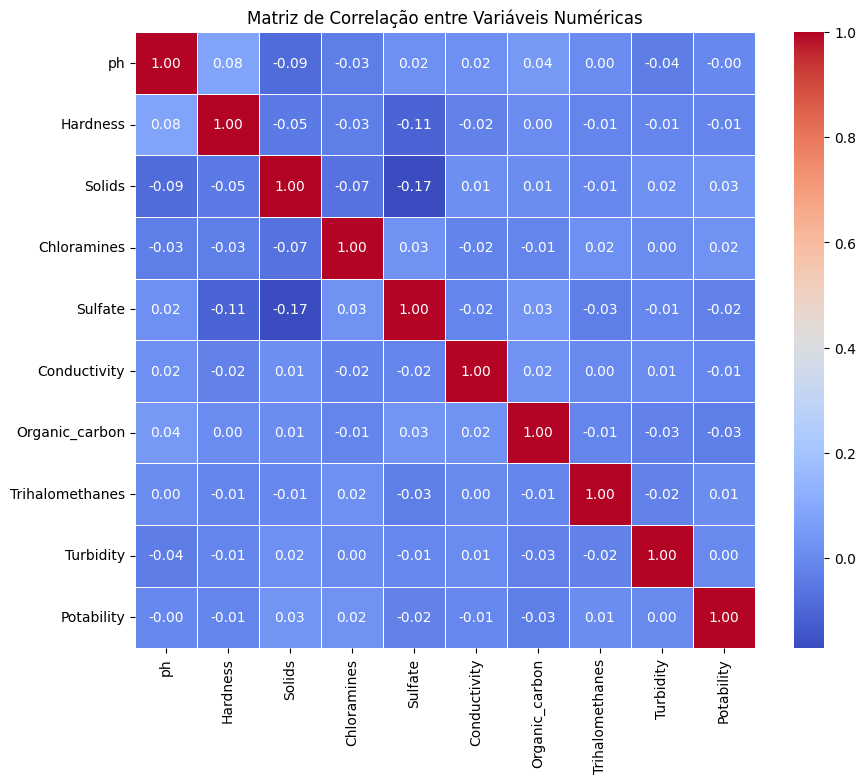

In [5]:
corr = dados.select_dtypes(include=['float64', 'int64']).corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlação entre Variáveis Numéricas')
plt.show()

Após a construção da matriz de correlação fica claro que as variavéis não tem quase nenhuma relação linear

### Tratamento de dados

In [6]:
dados.isnull().sum()

,0
ph,491
Hardness,0
Solids,0
Chloramines,0
Sulfate,781
Conductivity,0
Organic_carbon,0
Trihalomethanes,162
Turbidity,0
Potability,0


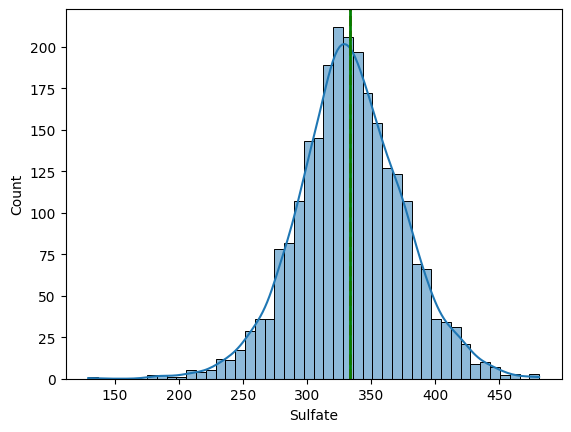

In [7]:
media = dados['Sulfate'].mean()
mediana = dados['Sulfate'].median()

sns.histplot(data=dados, x='Sulfate', kde=True)
plt.axvline(media, color='red', linestyle='--', linewidth=2, label=f'Média: {media:.2f}')
plt.axvline(mediana, color='green', linestyle='-', linewidth=2, label=f'Mediana: {media:.2f}')

plt.show()

# Media e Mediana são basicamente as mesmas Media = 333.77 e Mediana = 333.07, logo a distribuição dos dados é simétrica

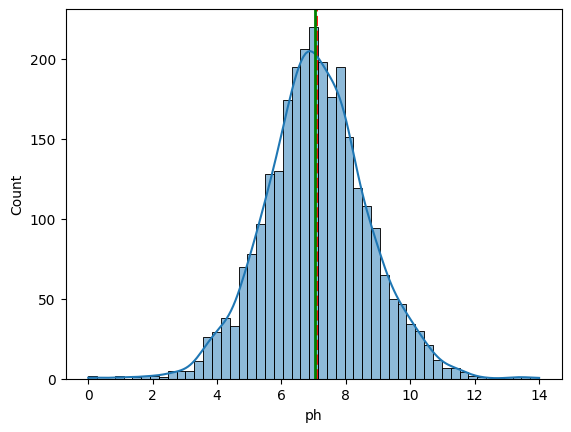

In [8]:
media = dados['ph'].mean()
mediana = dados['ph'].median()

sns.histplot(data=dados, x='ph', kde=True)
plt.axvline(media, color='red', linestyle='--', linewidth=2, label=f'Média: {media:.2f}')
plt.axvline(mediana, color='green', linestyle='-', linewidth=2, label=f'Mediana: {media:.2f}')

plt.show()

# Media e Mediana são basicamente as mesmas Media = 7.08 e Mediana = 7.03, logo a distribuição dos dados é simétrica

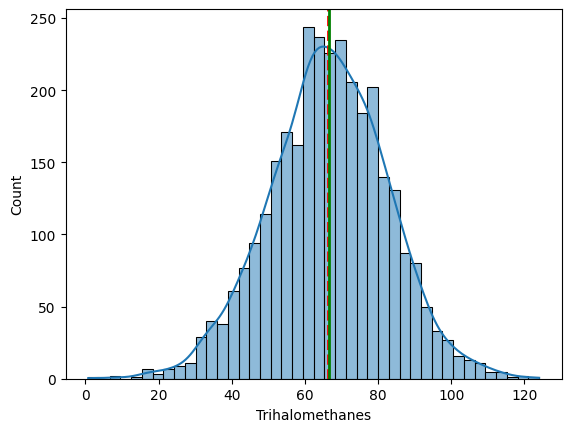

In [9]:
media = dados['Trihalomethanes'].mean()
mediana = dados['Trihalomethanes'].median()

sns.histplot(data=dados, x='Trihalomethanes', kde=True)
plt.axvline(media, color='red', linestyle='--', linewidth=2, label=f'Média: {media:.2f}')
plt.axvline(mediana, color='green', linestyle='-', linewidth=2, label=f'Mediana: {media:.2f}')

plt.show()
# Media e Mediana são basicamente as mesmas Media = 66.39 e Mediana = 66.62, logo a distribuição dos dados é simétrica

Visto que a distribuição das variáveis com valores `NAN` é simétrica, ireo substituir os dados faltantes pela media

In [10]:
dados.columns

Index(['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 'Conductivity',
       'Organic_carbon', 'Trihalomethanes', 'Turbidity', 'Potability'],
      dtype='object')

In [11]:
df = dados.copy()
df['Sulfate'] = df['Sulfate'].fillna(df['Sulfate'].mean())
df['ph'] = df['ph'].fillna(df['ph'].mean())
df['Trihalomethanes'] = df['Trihalomethanes'].fillna(df['Trihalomethanes'].mean())
df.isna().sum()

,0
ph,0
Hardness,0
Solids,0
Chloramines,0
Sulfate,0
Conductivity,0
Organic_carbon,0
Trihalomethanes,0
Turbidity,0
Potability,0


In [12]:
#verificando se há dados nulos
dados.duplicated().sum()

np.int64(0)

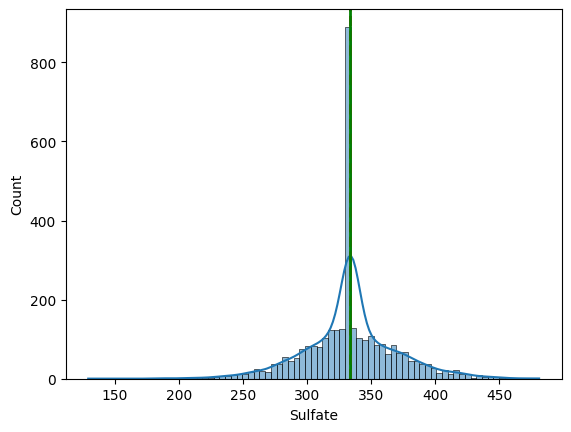

In [13]:
media = df['Sulfate'].mean()
mediana = df['Sulfate'].median()

sns.histplot(data=df, x='Sulfate', kde=True)
plt.axvline(media, color='red', linestyle='--', linewidth=2, label=f'Média: {media:.2f}')
plt.axvline(mediana, color='green', linestyle='-', linewidth=2, label=f'Mediana: {media:.2f}')

plt.show()

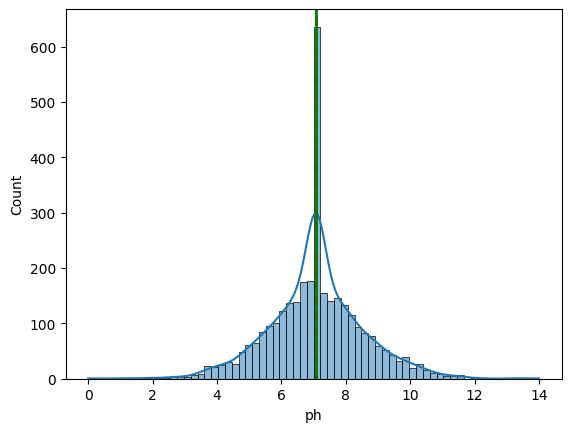

In [14]:
media = df['ph'].mean()
mediana = df['ph'].median()

sns.histplot(data=df, x='ph', kde=True)
plt.axvline(media, color='red', linestyle='--', linewidth=2, label=f'Média: {media:.2f}')
plt.axvline(mediana, color='green', linestyle='-', linewidth=2, label=f'Mediana: {media:.2f}')

plt.show()


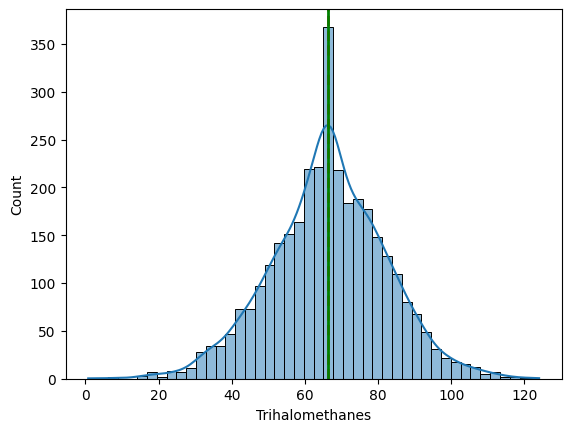

In [15]:
media = df['Trihalomethanes'].mean()
mediana = df['Trihalomethanes'].median()

sns.histplot(data=df, x='Trihalomethanes', kde=True)
plt.axvline(media, color='red', linestyle='--', linewidth=2, label=f'Média: {media:.2f}')
plt.axvline(mediana, color='green', linestyle='-', linewidth=2, label=f'Mediana: {media:.2f}')

plt.show()

## Treinar modelo

### Separar os dados treino e teste

In [16]:
X = df.drop('Potability', axis=1)
y = df['Potability']

In [17]:
y.value_counts(normalize=True)*100

,proportion
Potability,
0,60.989011
1,39.010989


* 60/40 ou 70/30: Desbalanceamento leve
* 80/20 ou 90/10: Desbalanceamento moderado
* 99/1: Desbalanceamento extremo

In [18]:
from sklearn.model_selection import train_test_split

X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

### Modelo XGBoost

In [19]:
import xgboost as xgb

`scale_pos_weight` - Ele funciona dando um peso maior para o erro cometido na classe minoritária durante o treino.

In [20]:
escala_peso = (y_treino == 0).sum() / (y_treino == 1).sum()
escala_peso

np.float64(1.563600782778865)

In [21]:
modelo = xgb.XGBClassifier(scale_pos_weight=escala_peso, random_state=42)
modelo.fit(X_treino, y_treino)
y_pred = modelo.predict(X_teste)

### Avaliando modelo

In [22]:
from sklearn.metrics import classification_report, RocCurveDisplay, ConfusionMatrixDisplay

In [23]:
print(classification_report(y_teste, y_pred))

              precision    recall  f1-score   support

           0       0.67      0.74      0.71       400
           1       0.52      0.43      0.47       256

    accuracy                           0.62       656
   macro avg       0.60      0.59      0.59       656
weighted avg       0.61      0.62      0.62       656



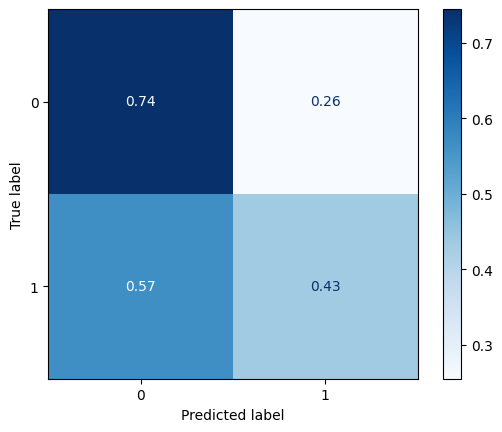

In [24]:
ConfusionMatrixDisplay.from_estimator(modelo, X_teste, y_teste, normalize='true', cmap='Blues');

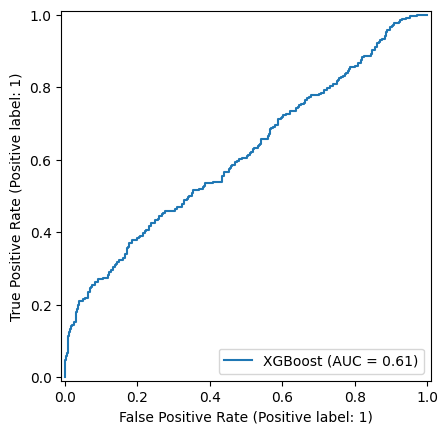

In [25]:
RocCurveDisplay.from_estimator(modelo, X_teste, y_teste, name='XGBoost')

## Desvendando o problema

Após o treinamento do modelo e análise das métricas percebi uma má perfomace o que é de certa forma esperado, pois pela matriz de correlação as variáveis são baixamente correlacionadas. Como também criei uma hipótese que as variaveis com valores faltantes, após o preenchimento de valores nulos com a media da variavél, o modelo pode começar a achar que o valor $333,77$ tem um significado místico ou especial para a potabilidade.
Por isso, testarei o **Iterative Imputer** para preencher os valores nulos com outra lógica

### Iterative Imputer

O **IterativeImputer** funciona através de um processo chamado MICE (Multivariate Imputation by Chained Equations). Imagine que ele trata cada coluna com valores faltantes como um pequeno problema de regressão dentro do seu próprio dataset:

1. **O Preenchimento Inicial:** Primeiro, ele preenche todos os nulos (ph, Sulfate, Trihalomethanes) com a média apenas temporariamente para ter um ponto de partida.

2. **A Estimativa do Sulfato:** Ele isola a coluna Sulfate. Ele usa todas as outras colunas (ph, Hardness, Chloramines, etc.) como variáveis preditoras para "prever" quais seriam os valores reais nos buracos do Sulfate.

3. **A Estimativa do pH:** Agora que ele tem valores melhores para o Sulfate, ele faz o mesmo para o ph. Ele usa as outras colunas (incluindo o Sulfate recém-estimado) para prever o ph.

4. **O Ciclo (Iteração):** Ele repete esse processo para todas as colunas com nulos várias vezes (max_iter=10). A cada rodada, os valores ficam mais precisos e condizentes com a realidade química daquela amostra de água específica.

In [26]:
from sklearn.preprocessing import StandardScaler
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

In [27]:
df_2 = dados.copy()

In [28]:
df_2.isna().sum()

,0
ph,491
Hardness,0
Solids,0
Chloramines,0
Sulfate,781
Conductivity,0
Organic_carbon,0
Trihalomethanes,162
Turbidity,0
Potability,0


In [29]:
X = df_2.drop('Potability', axis=1)
y = df_2['Potability']

#### Escalonando e aplicado a imputação

In [30]:
# Escalonamento
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Imputação
imputer = IterativeImputer(max_iter=10, random_state=42)
X_imputado_escalado = imputer.fit_transform(X_scaled)

X_imputado = scaler.inverse_transform(X_imputado_escalado)
X_final = pd.DataFrame(X_imputado, columns=X.columns)

In [31]:
X_final

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity
0,7.196510,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135
1,3.716080,129.422921,18630.057858,6.635246,343.493893,592.885359,15.180013,56.329076,4.500656
2,8.099124,224.236259,19909.541732,9.275884,334.207975,418.606213,16.868637,66.420093,3.055934
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075
...,...,...,...,...,...,...,...,...,...
3271,4.668102,193.681735,47580.991603,7.166639,359.948574,526.424171,13.894419,66.687695,4.435821
3272,7.808856,193.553212,17329.802160,8.061362,341.398299,392.449580,19.903225,66.424821,2.798243
3273,9.419510,175.762646,33155.578218,7.350233,327.991026,432.044783,11.039070,69.845400,3.298875
3274,5.126763,230.603758,11983.869376,6.303357,333.375468,402.883113,11.168946,77.488213,4.708658


In [32]:
X_final.isna().sum()

,0
ph,0
Hardness,0
Solids,0
Chloramines,0
Sulfate,0
Conductivity,0
Organic_carbon,0
Trihalomethanes,0
Turbidity,0


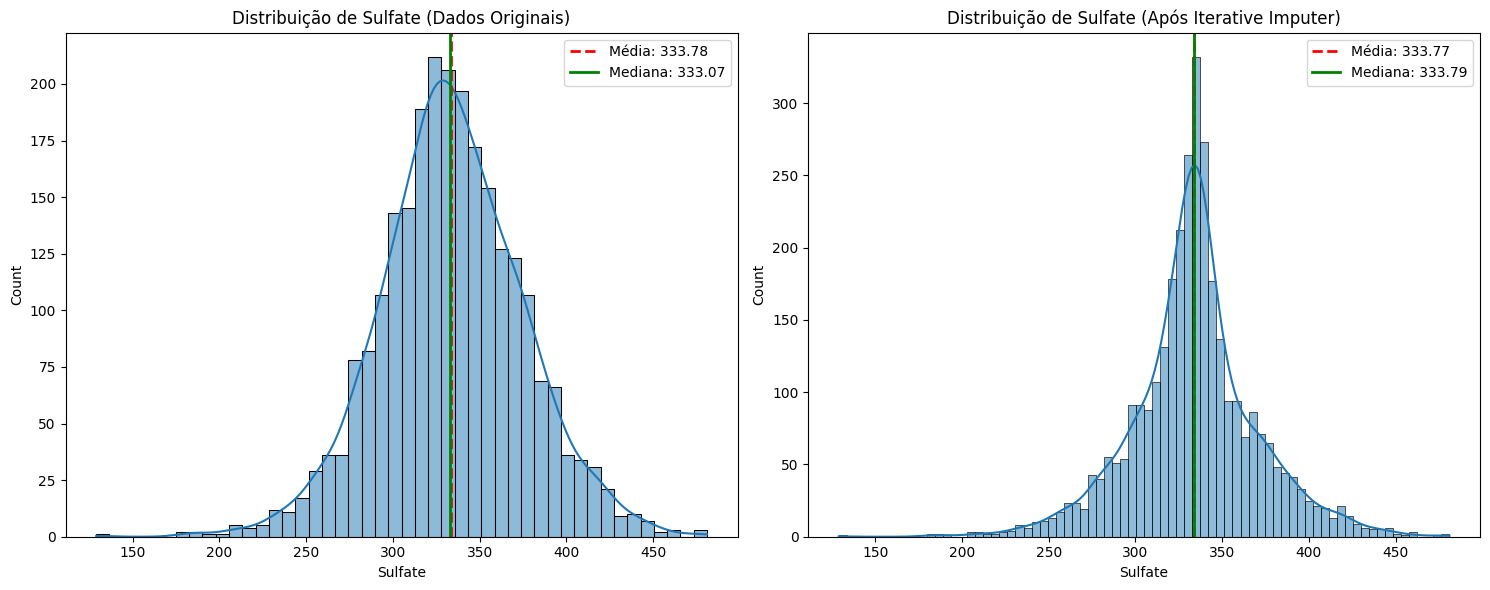

In [33]:
media_original = dados['Sulfate'].mean()
mediana_original = dados['Sulfate'].median()

media_apos_imputacao = X_final['Sulfate'].mean()
mediana_apos_imputacao = X_final['Sulfate'].median()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.histplot(data=dados, x='Sulfate', kde=True, ax=axes[0])
axes[0].set_title('Distribuição de Sulfate (Dados Originais)')
axes[0].axvline(media_original, color='red', linestyle='--', linewidth=2, label=f'Média: {media_original:.2f}')
axes[0].axvline(mediana_original, color='green', linestyle='-', linewidth=2, label=f'Mediana: {mediana_original:.2f}')
axes[0].legend()

sns.histplot(data=X_final, x='Sulfate', kde=True, ax=axes[1])
axes[1].set_title('Distribuição de Sulfate (Após Iterative Imputer)')
axes[1].axvline(media_apos_imputacao, color='red', linestyle='--', linewidth=2, label=f'Média: {media_apos_imputacao:.2f}')
axes[1].axvline(mediana_apos_imputacao, color='green', linestyle='-', linewidth=2, label=f'Mediana: {mediana_apos_imputacao:.2f}')
axes[1].legend()

plt.tight_layout()
plt.show()

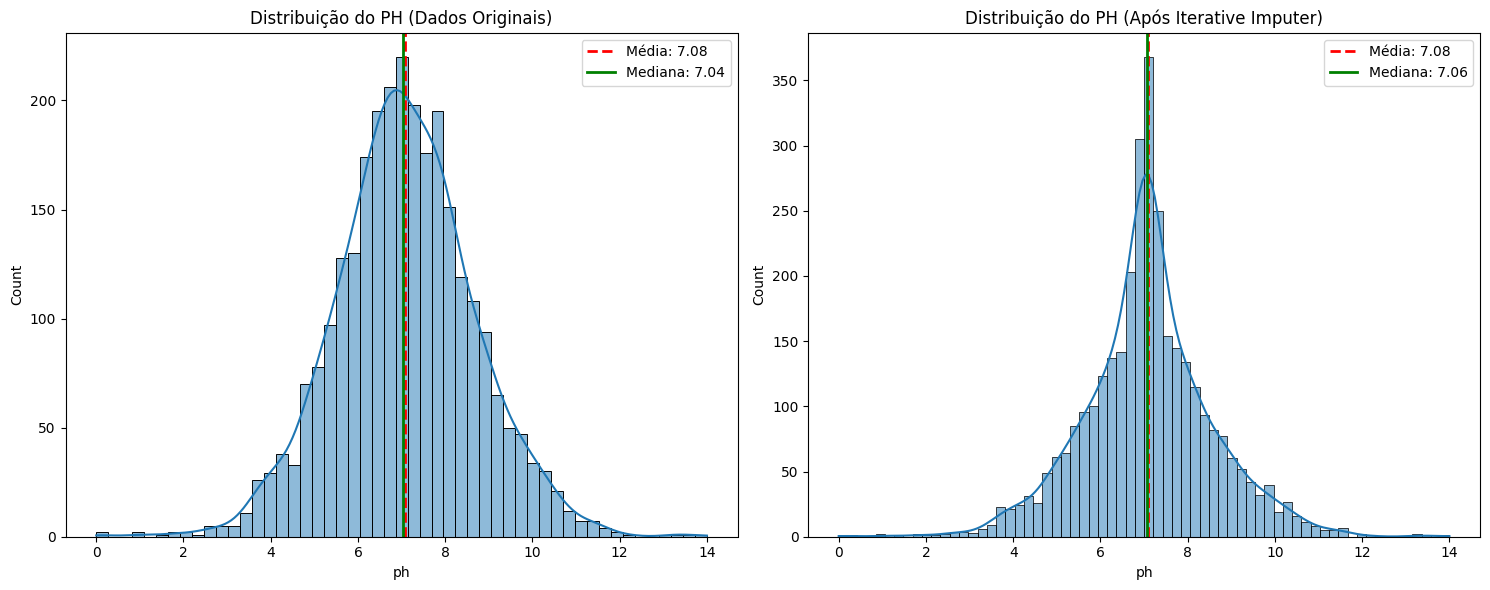

In [34]:
media_original = dados['ph'].mean()
mediana_original = dados['ph'].median()

media_apos_imputacao = X_final['ph'].mean()
mediana_apos_imputacao = X_final['ph'].median()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.histplot(data=dados, x='ph', kde=True, ax=axes[0])
axes[0].set_title('Distribuição do PH (Dados Originais)')
axes[0].axvline(media_original, color='red', linestyle='--', linewidth=2, label=f'Média: {media_original:.2f}')
axes[0].axvline(mediana_original, color='green', linestyle='-', linewidth=2, label=f'Mediana: {mediana_original:.2f}')
axes[0].legend()

sns.histplot(data=X_final, x='ph', kde=True, ax=axes[1])
axes[1].set_title('Distribuição do PH (Após Iterative Imputer)')
axes[1].axvline(media_apos_imputacao, color='red', linestyle='--', linewidth=2, label=f'Média: {media_apos_imputacao:.2f}')
axes[1].axvline(mediana_apos_imputacao, color='green', linestyle='-', linewidth=2, label=f'Mediana: {mediana_apos_imputacao:.2f}')
axes[1].legend()

plt.tight_layout()
plt.show()

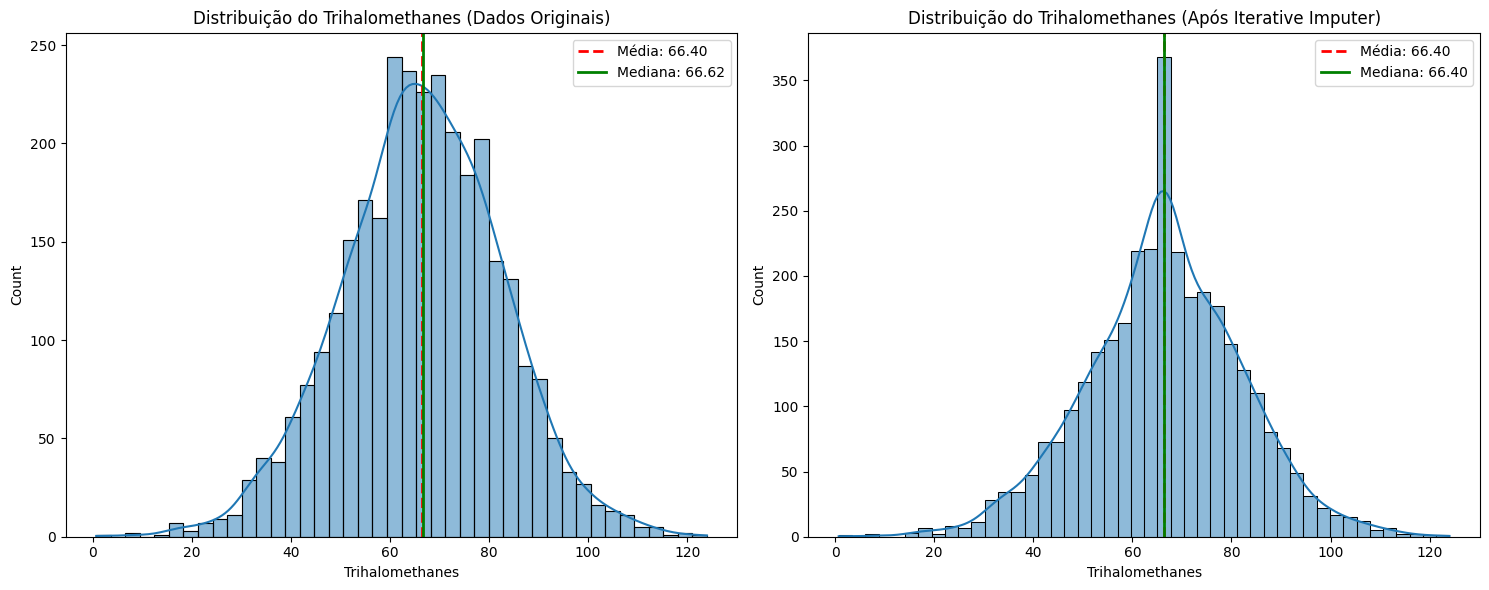

In [35]:
media_original = dados['Trihalomethanes'].mean()
mediana_original = dados['Trihalomethanes'].median()

media_apos_imputacao = X_final['Trihalomethanes'].mean()
mediana_apos_imputacao = X_final['Trihalomethanes'].median()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.histplot(data=dados, x='Trihalomethanes', kde=True, ax=axes[0])
axes[0].set_title('Distribuição do Trihalomethanes (Dados Originais)')
axes[0].axvline(media_original, color='red', linestyle='--', linewidth=2, label=f'Média: {media_original:.2f}')
axes[0].axvline(mediana_original, color='green', linestyle='-', linewidth=2, label=f'Mediana: {mediana_original:.2f}')
axes[0].legend()

sns.histplot(data=X_final, x='Trihalomethanes', kde=True, ax=axes[1])
axes[1].set_title('Distribuição do Trihalomethanes (Após Iterative Imputer)')
axes[1].axvline(media_apos_imputacao, color='red', linestyle='--', linewidth=2, label=f'Média: {media_apos_imputacao:.2f}')
axes[1].axvline(mediana_apos_imputacao, color='green', linestyle='-', linewidth=2, label=f'Mediana: {mediana_apos_imputacao:.2f}')
axes[1].legend()

plt.tight_layout()
plt.show()

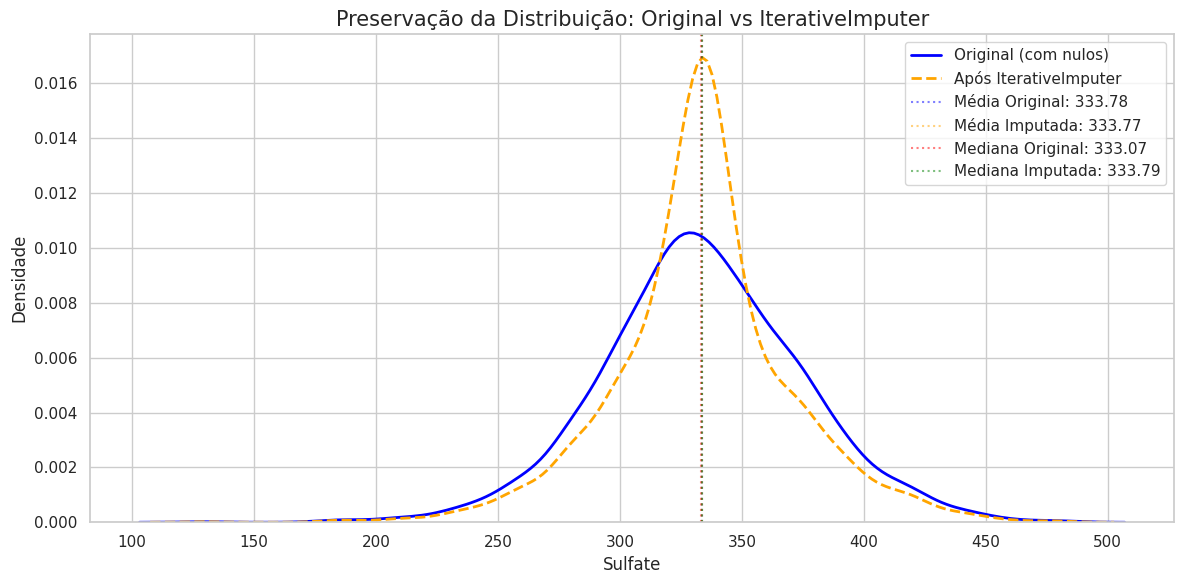

In [36]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# Comparando a distribuição de Sulfate (ou a que você preferir)
# Supondo que 'df_original' tenha nulos e 'df_final' seja o após IterativeImputer
ax = sns.kdeplot(dados['Sulfate'].dropna(), label='Original (com nulos)', color='blue', linewidth=2)
sns.kdeplot(X_final['Sulfate'], label='Após IterativeImputer', color='orange', linestyle='--', linewidth=2)

# Adicionando linhas de média/mediana para provar seu ponto
plt.axvline(dados['Sulfate'].mean(), color='blue', alpha=0.5, linestyle=':', label=f'Média Original: {dados['Sulfate'].mean():.2f}')
plt.axvline(X_final['Sulfate'].mean(), color='orange', alpha=0.5, linestyle=':', label=f'Média Imputada: {X_final['Sulfate'].mean():.2f}')
plt.axvline(dados['Sulfate'].median(), color='red', alpha=0.5, linestyle=':', label=f'Mediana Original: {dados['Sulfate'].median():.2f}')
plt.axvline(X_final['Sulfate'].median(), color='green', alpha=0.5, linestyle=':', label=f'Mediana Imputada: {X_final['Sulfate'].median():.2f}')

plt.title('Preservação da Distribuição: Original vs IterativeImputer', fontsize=15)
plt.xlabel('Sulfate')
plt.ylabel('Densidade')
plt.legend()

plt.tight_layout()
plt.savefig('distribuicao_sulfato.png')
plt.show()


## Separando em treino e teste

In [37]:
X_treino, X_teste, y_treino, y_teste = train_test_split(X_final, y, test_size=0.2, stratify=y, random_state=42)

### Treinando modelo

In [38]:
modelo_com_imputacao = xgb.XGBClassifier(scale_pos_weight=escala_peso, random_state=42)
modelo_com_imputacao.fit(X_treino, y_treino)
y_pred = modelo_com_imputacao.predict(X_teste)

### Avaliando modelo

In [39]:
print(classification_report(y_teste, y_pred))

              precision    recall  f1-score   support

           0       0.67      0.72      0.70       400
           1       0.51      0.45      0.48       256

    accuracy                           0.62       656
   macro avg       0.59      0.59      0.59       656
weighted avg       0.61      0.62      0.61       656



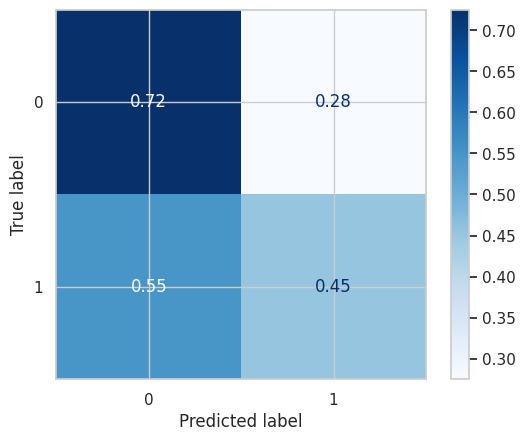

In [40]:
ConfusionMatrixDisplay.from_estimator(modelo_com_imputacao, X_teste, y_teste, normalize='true', cmap='Blues');

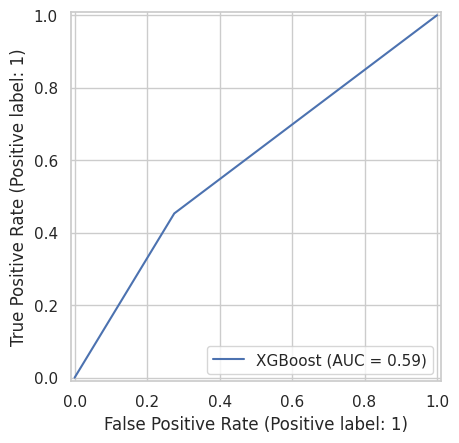

In [41]:
RocCurveDisplay.from_predictions(y_teste, y_pred, name='XGBoost')

## Ajustando Hiperpâmetros

In [42]:
from sklearn.model_selection import GridSearchCV

In [43]:
params = {
        'learning_rate': [0.1, 0.2, 0.3],
        'max_depth': [0, 2, 4, 6, 10],
        'colsample_bytree': [0.1, 0.5, 1],
        'n_estimators': [10, 25, 50],
}

In [44]:
modelo = xgb.XGBClassifier(random_state=42)

In [45]:
grid_search_cv = GridSearchCV(estimator=modelo, param_grid=params, cv=4, scoring='accuracy', verbose=1)

grid_search_cv.fit(X, y)

Fitting 4 folds for each of 135 candidates, totalling 540 fits


GridSearchCV(cv=4,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, feature_weights=None,
                                     gamma=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=Non...
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             param_grid={'colsample_bytree': [0.1, 0.5, 1],
                         'learning_rate': [0.1, 0.2, 0.3],
                         'max_depth': [0, 2, 4, 6, 10],
                         'n_estimators': [10, 25, 50]},
             scoring='accuracy', verbose=1)

In [46]:
print('Melhores parametros encontrados: ', grid_search_cv.best_params_)
print('Acuracia: ', grid_search_cv.best_score_)

Melhores parametros encontrados:  {'colsample_bytree': 1, 'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 10}
Acuracia:  0.6221001221001221


### Analisando as métricas após ajuste dos hiperparâmetros

In [47]:
modelo_ajustado = xgb.XGBClassifier(scale_pos_weight=escala_peso, random_state=42, colsample_bytree=1, learning_rate=0.1, max_depth=6, n_estimators=10)

modelo_ajustado.fit(X_treino, y_treino)

y_pred = modelo_ajustado.predict(X_teste)

In [48]:
report = classification_report(y_teste, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.70      0.75      0.72       400
           1       0.56      0.50      0.53       256

    accuracy                           0.65       656
   macro avg       0.63      0.62      0.63       656
weighted avg       0.65      0.65      0.65       656



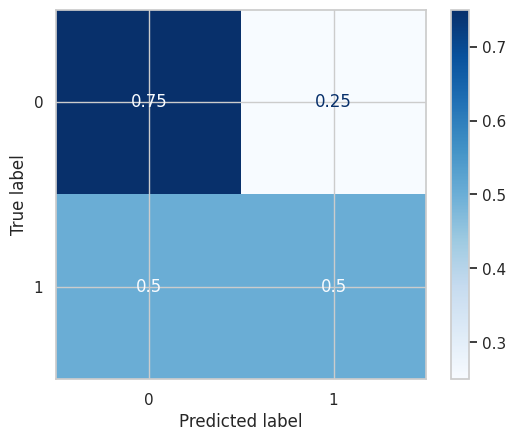

In [49]:
ConfusionMatrixDisplay.from_estimator(modelo_ajustado, X_teste, y_teste, normalize='true', cmap='Blues');

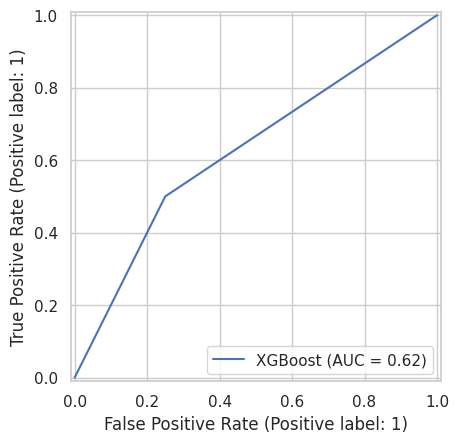

In [50]:
RocCurveDisplay.from_predictions(y_teste, y_pred, name='XGBoost')

## Engenharia de atributos

### Inidicadores de padrões

In [57]:
# Criando flags baseadas em limites conhecidos
X_final['ph_ideal'] = X_final['ph'].between(6.5, 8.5).astype(int)
X_final['solids_high'] = (X_final['Solids'] > 1000).astype(int)
X_final['chloramines_safe'] = (X_final['Chloramines'] <= 4).astype(int)

### Atributos de Interação

In [53]:
# Criando interações simples
X_final['hardness_solids_ratio'] = X_final['Hardness'] / (X_final['Solids'] + 1e-5)
X_final['chem_interaction'] = X_final['Chloramines'] * X_final['Sulfate']

### "Score" de Inadequação

In [59]:
# Criando um score de alertas
alertas = [
    (X_final['ph'] < 6.5) | (X_final['ph'] > 8.5),
    (X_final['Sulfate'] > 250),
    (X_final['Chloramines'] > 4),
    (X_final['Organic_carbon'] > 10)
]

X_final['alert_count'] = sum(alertas).astype(int)

### Treinado modelo com novas variáveis

In [60]:
X_treino, X_teste, y_treino, y_teste = train_test_split(X_final, y, test_size=0.2, stratify=y, random_state=42)

In [61]:
modelo_ajustado = xgb.XGBClassifier(scale_pos_weight=escala_peso, random_state=42, colsample_bytree=1, learning_rate=0.1, max_depth=6, n_estimators=10)

modelo_ajustado.fit(X_treino, y_treino)

y_pred = modelo_ajustado.predict(X_teste)

In [62]:
report = classification_report(y_teste, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.70      0.75      0.72       400
           1       0.56      0.49      0.52       256

    accuracy                           0.65       656
   macro avg       0.63      0.62      0.62       656
weighted avg       0.64      0.65      0.65       656



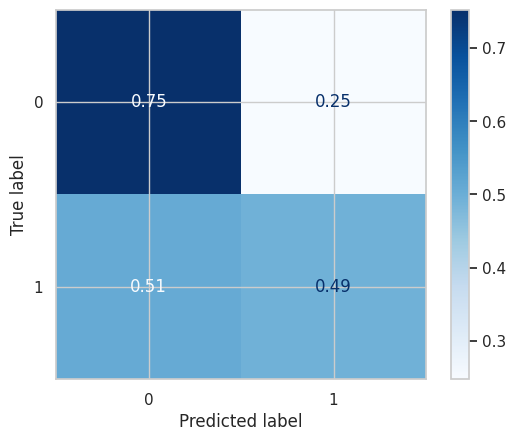

In [63]:
ConfusionMatrixDisplay.from_estimator(modelo_ajustado, X_teste, y_teste, normalize='true', cmap='Blues');

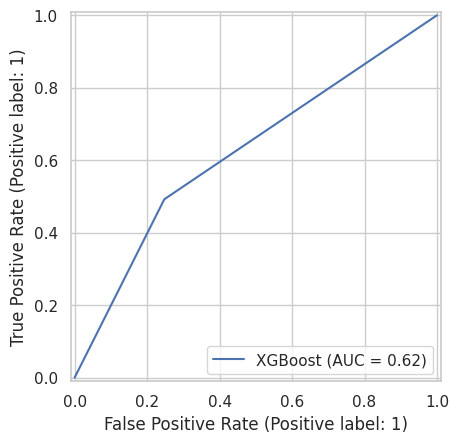

In [64]:
RocCurveDisplay.from_predictions(y_teste, y_pred, name='XGBoost')